# Módulo 1 — Dia 3
## Análise de Erros

Exercícios sobre representação em ponto flutuante, erros de arredondamento e truncamento,
estabilidade numérica e condicionamento de problemas — encerrando com o **exercício integrador**
que reúne todo o fluxo do módulo.

## 1. Ponto flutuante e erros de arredondamento

### Exercício 3.1

In [1]:
print(0.1 + 0.2)
print(0.1 + 0.2 == 0.3)


0.30000000000000004
False


In [2]:
import numpy as np

eps = np.finfo(float).eps
print(f"Épsilon de máquina (float64): {eps:.3e}")


Épsilon de máquina (float64): 2.220e-16


### Exercício 3.2 — comparando floats corretamente

Complete a função `sao_iguais` para comparar dois números de ponto flutuante usando uma
tolerância, em vez de `==`.

In [3]:
import math

def sao_iguais(a, b, tolerancia=1e-9):
    """Compara dois floats com tolerância, em vez de igualdade exata."""
    # TODO: implemente usando abs(a - b) < tolerancia
    return abs(a - b) < tolerancia


print(sao_iguais(0.1 + 0.2, 0.3))          # deve ser True
print(math.isclose(0.1 + 0.2, 0.3))        # equivalente, da biblioteca padrão


True
True


## 2. Erros de truncamento

### Exercício 3.3 — série de Taylor para e^x

Complete a função abaixo e reproduza a tabela de erro vs. número de termos vista em aula.

In [4]:
def exp_aproximado(x, n_termos):
    """Aproxima e^x pela série de Taylor truncada em n_termos."""
    soma = 0.0
    for k in range(n_termos):
        soma += x**k / math.factorial(k)
    return soma


valor_real = math.exp(1)
print(f"{'n':>3} {'aproximado':>12} {'erro':>12}")
for n in [1, 2, 5, 10, 15]:
    aprox = exp_aproximado(1, n)
    erro = abs(aprox - valor_real)
    print(f"{n:3d} {aprox:12.6f} {erro:12.2e}")


  n   aproximado         erro
  1     1.000000     1.72e+00
  2     2.000000     7.18e-01
  5     2.708333     9.95e-03
 10     2.718282     3.03e-07
 15     2.718282     8.15e-13


## 3. Estabilidade numérica

### Exercício 3.4 — cancelamento catastrófico

Compare as duas versões da fórmula de Bhaskara abaixo para um caso em que `b` é muito maior que
`4ac`.

In [5]:
def raiz_instavel(a, b, c):
    disc = math.sqrt(b**2 - 4*a*c)
    x1 = (-b + disc) / (2*a)
    x2 = (-b - disc) / (2*a)
    return x1, x2


def raiz_estavel(a, b, c):
    disc = math.sqrt(b**2 - 4*a*c)
    if b >= 0:
        x1 = (-b - disc) / (2*a)
        x2 = (2*c) / (-b - disc)
    else:
        x1 = (-b + disc) / (2*a)
        x2 = (2*c) / (-b + disc)
    return x1, x2


a, b, c = 1, 1e8, 1
print("Versão instável:", raiz_instavel(a, b, c))
print("Versão estável: ", raiz_estavel(a, b, c))
# Compare a raiz pequena nas duas versões — a diferença relativa mostra o efeito
# do cancelamento catastrófico.


Versão instável: (-7.450580596923828e-09, -100000000.0)
Versão estável:  (-100000000.0, -1e-08)


## 4. Condicionamento de problemas

### Exercício 3.5

In [6]:
A_bem = np.array([[2, 0], [0, 2]])
A_mal = np.array([[1, 1], [1, 1.0001]])

print("cond(A_bem) =", np.linalg.cond(A_bem))
print("cond(A_mal) =", np.linalg.cond(A_mal))

b = np.array([2.0, 2.0])
b_perturbado = np.array([2.0, 2.0001])   # pequena mudança na 4a casa decimal

x_bem = np.linalg.solve(A_bem, b)
x_bem_pert = np.linalg.solve(A_bem, b_perturbado)
x_mal = np.linalg.solve(A_mal, b)
x_mal_pert = np.linalg.solve(A_mal, b_perturbado)

print("\nEfeito de uma pequena perturbação em b:")
print("Sistema bem condicionado: variação em x =", x_bem_pert - x_bem)
print("Sistema mal condicionado: variação em x =", x_mal_pert - x_mal)


cond(A_bem) = 1.0
cond(A_mal) = 40002.000074915224

Efeito de uma pequena perturbação em b:
Sistema bem condicionado: variação em x = [0.e+00 5.e-05]
Sistema mal condicionado: variação em x = [-1.  1.]


---
## 5. Exercício integrador

Aplique, nesta seção, todo o fluxo do módulo — do problema real à análise de erros — retomando a
bola em queda livre do Dia 1.

**Roteiro:**
1. Implemente a derivada numérica (diferença finita progressiva) da posição para estimar a
   velocidade em t = 0,5 s.
2. Compare com a velocidade analítica v(t) = −g·t.
3. Teste pelo menos 5 valores de h e calcule o erro absoluto em cada caso.
4. Plote erro vs. h em escala log-log.
5. Escreva uma conclusão relacionando o gráfico aos conceitos do módulo.

In [7]:
def posicao(t, h0=5.0, g=9.81):
    return h0 - 0.5 * g * t**2


def derivada_numerica(f, t, passo):
    """Derivada por diferença finita progressiva."""
    return (f(t + passo) - f(t)) / passo


g = 9.81
t0 = 0.5
velocidade_analitica = -g * t0   # v(t) = dy/dt = -g*t

passos_h = [1e-1, 1e-3, 1e-5, 1e-8, 1e-10, 1e-12, 1e-14]
erros = []

print(f"{'h':>10} {'v_numerica':>14} {'erro absoluto':>16}")
for h_passo in passos_h:
    v_num = derivada_numerica(posicao, t0, h_passo)
    erro = abs(v_num - velocidade_analitica)
    erros.append(erro)
    print(f"{h_passo:10.0e} {v_num:14.6f} {erro:16.3e}")


         h     v_numerica    erro absoluto
     1e-01      -5.395500        4.905e-01
     1e-03      -4.909905        4.905e-03
     1e-05      -4.905049        4.905e-05
     1e-08      -4.905000        5.057e-08
     1e-10      -4.905001        8.499e-07
     1e-12      -4.904521        4.788e-04
     1e-14      -4.884981        2.002e-02


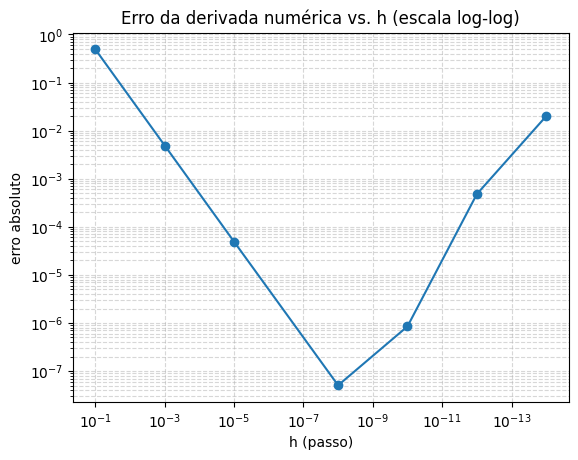

In [8]:
import matplotlib.pyplot as plt

plt.loglog(passos_h, erros, marker="o")
plt.xlabel("h (passo)")
plt.ylabel("erro absoluto")
plt.title("Erro da derivada numérica vs. h (escala log-log)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.gca().invert_xaxis()
plt.show()


### Sua conclusão

Escreva aqui (3–5 linhas) relacionando o gráfico ao que vimos hoje: em que região do gráfico o
**erro de truncamento** domina? Em que região o **erro de arredondamento** passa a dominar? Existe
um h aproximadamente ótimo?

*(resposta do aluno aqui)*

---
### Não esqueça

Ao terminar, faça commit e push deste notebook para o repositório GitHub criado no Dia 2:

```bash
git add dia3_exercicios.ipynb
git commit -m "Dia 3: exercício integrador — análise de erros"
git push
```